# Lab Experiment 5: Linear Regression through Gradient Descent
**Aim:** To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on the Student Performance dataset (UCI).


**Name:** Reno Reji Matthew(2547145)

### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

### 2. Download and Load the Dataset

In [16]:
df = pd.read_csv('student_data/student-mat.csv', sep=';')
print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 3. Data Preprocessing

In [4]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())
print("\nData types:\n", df.dtypes.value_counts())

Total missing values: 0

Data types:
 object    17
int64     16
Name: count, dtype: int64


In [5]:
# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True).astype(float)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding:

 (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,15.0,1.0,1.0,1.0,2.0,3.0,4.0,3.0,2.0,2.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0


### 4. Feature and Target Selection

In [6]:
# Target variable: G3 (final grade), Input features: all remaining columns
X = df_encoded.drop('G3', axis=1).values
y = df_encoded['G3'].values.reshape(-1, 1)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 41)
Target: (395, 1)


### 5. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (316, 41)
Testing set: (79, 41)


### 6. Feature Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add bias (intercept) column
X_train_final = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_final = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print("Final training matrix:", X_train_final.shape)

Final training matrix: (316, 42)


### 7. Linear Regression using Gradient Descent

In [9]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []
    for i in range(iterations):
        predictions = X.dot(theta)
        gradient = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradient
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

### 8. Experimenting with Different Learning Rates

In [10]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
iterations = 1000
results = {}

for lr in learning_rates:
    theta_init = np.zeros((X_train_final.shape[1], 1))
    theta, cost_history = gradient_descent(X_train_final, y_train, theta_init, lr, iterations)
    results[lr] = cost_history
    print(f"Learning rate = {lr} --> Final cost = {cost_history[-1]:.4f}")

Learning rate = 0.0001 --> Final cost = 51.0313


Learning rate = 0.001 --> Final cost = 9.2543


Learning rate = 0.01 --> Final cost = 1.4302


Learning rate = 0.1 --> Final cost = 1.4115


### 9. Loss (Cost) vs Number of Iterations

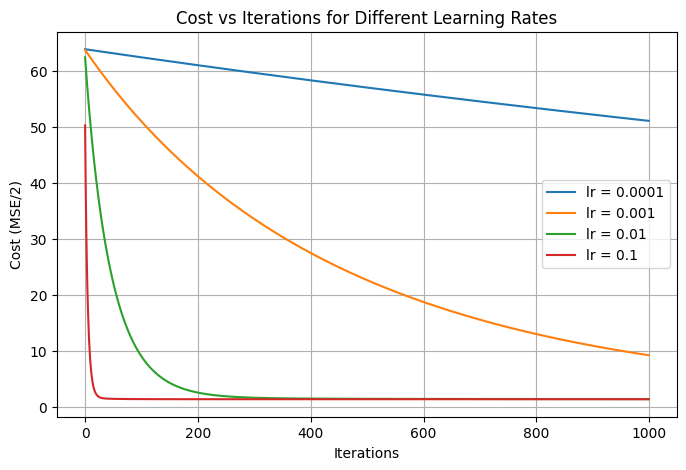

In [11]:
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(range(iterations), results[lr], label=f'lr = {lr}')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE/2)')
plt.title('Cost vs Iterations for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

### 10. Training the Final Model

In [12]:
best_lr = 0.1
theta_init = np.zeros((X_train_final.shape[1], 1))
theta_final, cost_history = gradient_descent(X_train_final, y_train, theta_init, best_lr, iterations)

print("Learning rate used:", best_lr)
print("Initial cost:", round(cost_history[0], 4))
print("Final cost:", round(cost_history[-1], 4))

Learning rate used: 0.1
Initial cost: 50.209
Final cost: 1.4115


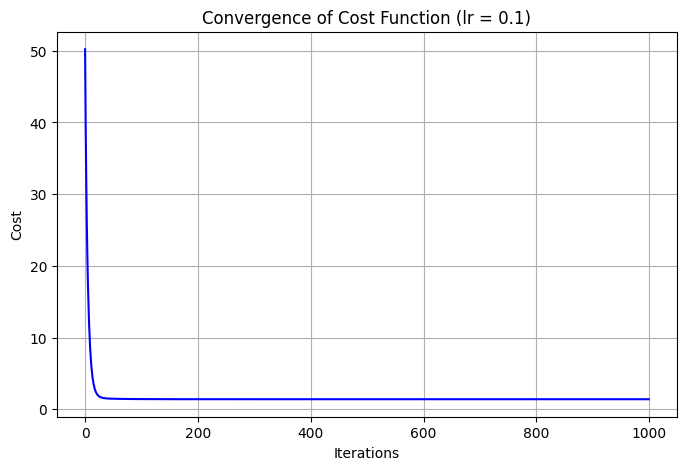

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, color='blue')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title(f'Convergence of Cost Function (lr = {best_lr})')
plt.grid(True)
plt.show()

### 11. Model Evaluation

In [14]:
y_pred = X_test_final.dot(theta_final)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE) :", round(mae, 4))
print("Mean Squared Error (MSE)  :", round(mse, 4))
print("Root Mean Squared Error   :", round(rmse, 4))
print("R2 Score                  :", round(r2, 4))

Mean Absolute Error (MAE) : 1.6467
Mean Squared Error (MSE)  : 5.6567
Root Mean Squared Error   : 2.3784
R2 Score                  : 0.7241


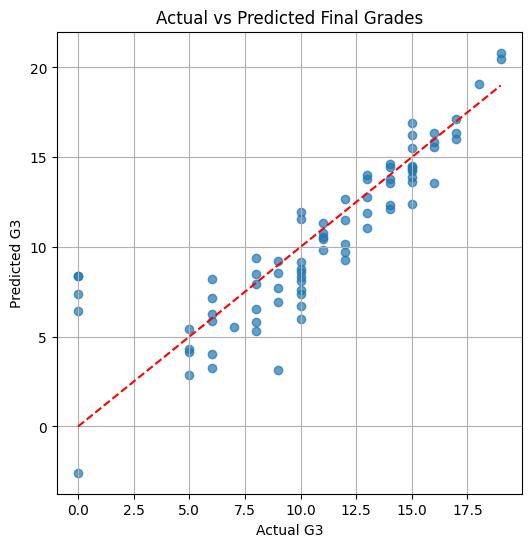

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Final Grades')
plt.grid(True)
plt.show()

### 12. Residual Plot

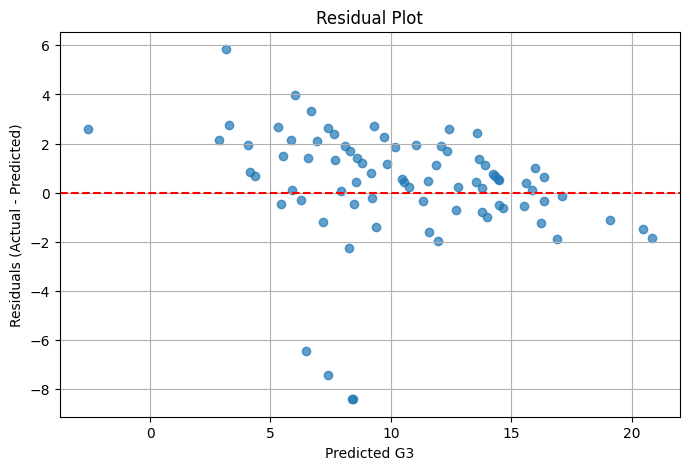

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted G3')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

### 13. Simple Linear Regression on a Single Feature (G2)

In [17]:
# Using only G2 (second period grade) so that the fitted line can be plotted
X_single = df_encoded[['G2']].values
y_single = df_encoded['G3'].values

scaler_single = StandardScaler()
X_single_scaled = scaler_single.fit_transform(X_single)

m_slope = 0.0
c_intercept = 0.0
lr_single = 0.05
iters_single = 1000
loss_history_single = []

for i in range(iters_single):
    y_hat = m_slope * X_single_scaled.flatten() + c_intercept
    error = y_hat - y_single
    loss_history_single.append(np.mean(error ** 2))

    dm = (2 / len(X_single_scaled)) * np.dot(error, X_single_scaled.flatten())
    dc = (2 / len(X_single_scaled)) * np.sum(error)

    m_slope -= lr_single * dm
    c_intercept -= lr_single * dc

print(f"Slope (m)     : {m_slope:.4f}")
print(f"Intercept (c) : {c_intercept:.4f}")
print(f"Final Loss    : {loss_history_single[-1]:.4f}")

Slope (m)     : 4.1403
Intercept (c) : 10.4152
Final Loss    : 3.7940


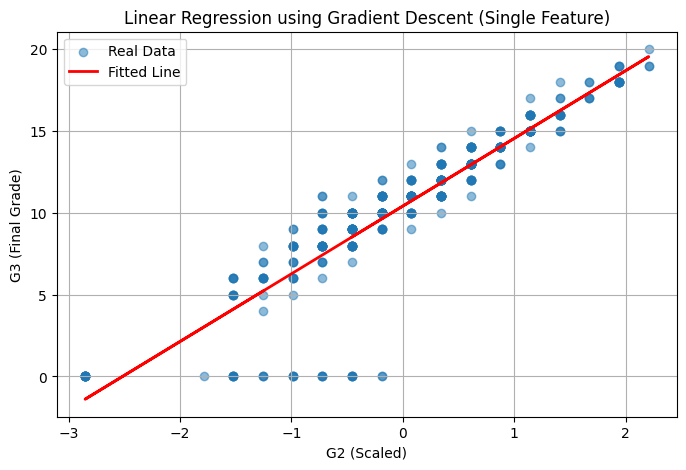

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(X_single_scaled, y_single, alpha=0.5, label='Real Data')
plt.plot(X_single_scaled, m_slope * X_single_scaled.flatten() + c_intercept,
         color='red', linewidth=2, label='Fitted Line')
plt.xlabel('G2 (Scaled)')
plt.ylabel('G3 (Final Grade)')
plt.title('Linear Regression using Gradient Descent (Single Feature)')
plt.legend()
plt.grid(True)
plt.show()

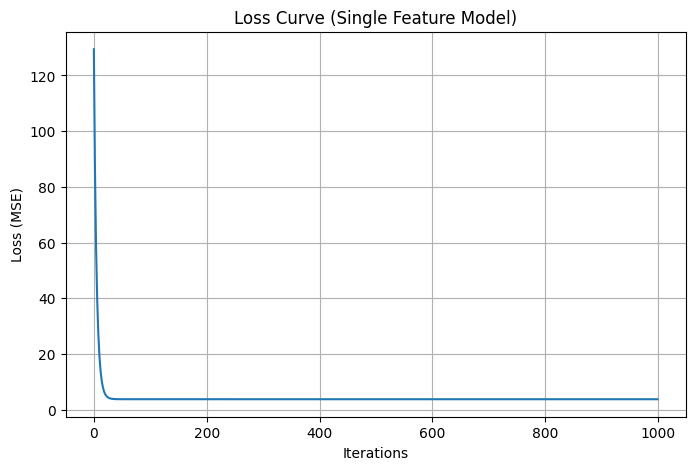

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_single)
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curve (Single Feature Model)')
plt.grid(True)
plt.show()

### 14. 3D Visualization of the Cost Surface and Gradient Descent Path

In [20]:
from mpl_toolkits.mplot3d import Axes3D

X_bias_single = np.c_[np.ones((len(X_single_scaled), 1)), X_single_scaled]
y_col = y_single.reshape(-1, 1)


def cost_2d(theta, X, y):
    predictions = X.dot(theta)
    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)


# Re-run gradient descent while storing the parameter path
theta_path = []
theta_v = np.zeros((2, 1))
for i in range(iters_single):
    theta_path.append(theta_v.copy())
    gradients = (1 / len(y_col)) * X_bias_single.T.dot(X_bias_single.dot(theta_v) - y_col)
    theta_v = theta_v - lr_single * gradients

theta_path = np.array(theta_path)
print("Final theta:", theta_v.ravel())

Final theta: [10.41518987  4.14034984]


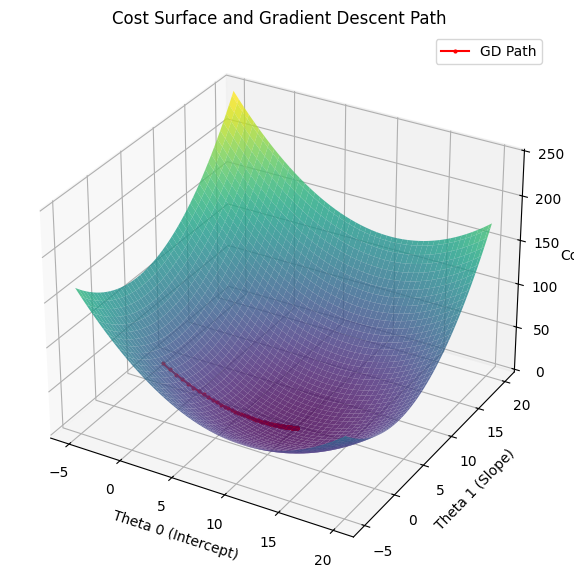

In [21]:
theta0_vals = np.linspace(-5, 20, 100)
theta1_vals = np.linspace(-5, 20, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = cost_2d(np.array([[T0[i, j]], [T1[i, j]]]), X_bias_single, y_col)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax.plot(theta_path[:, 0].ravel(), theta_path[:, 1].ravel(),
        [cost_2d(t, X_bias_single, y_col) for t in theta_path],
        color='red', marker='o', markersize=2, label='GD Path')
ax.set_xlabel('Theta 0 (Intercept)')
ax.set_ylabel('Theta 1 (Slope)')
ax.set_zlabel('Cost')
ax.set_title('Cost Surface and Gradient Descent Path')
ax.legend()
plt.show()

### 15. Comparison of Gradient Descent Variants

In [22]:
def batch_gradient_descent(X, y, learning_rate=0.05, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost_history.append(cost_2d(theta, X, y))
    return theta, cost_history


def mini_batch_gradient_descent(X, y, learning_rate=0.05, epochs=100, batch_size=32):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        idx = np.random.permutation(m)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, m, batch_size):
            X_b, y_b = X_s[i:i + batch_size], y_s[i:i + batch_size]
            gradients = (1 / len(X_b)) * X_b.T.dot(X_b.dot(theta) - y_b)
            theta = theta - learning_rate * gradients
        cost_history.append(cost_2d(theta, X, y))
    return theta, cost_history


def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        idx = np.random.permutation(m)
        X_s, y_s = X[idx], y[idx]
        for i in range(m):
            xi, yi = X_s[i:i + 1], y_s[i:i + 1]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
        cost_history.append(cost_2d(theta, X, y))
    return theta, cost_history

In [23]:
theta_batch, cost_batch = batch_gradient_descent(X_bias_single, y_col)
theta_mini, cost_mini = mini_batch_gradient_descent(X_bias_single, y_col)
theta_sgd, cost_sgd = stochastic_gradient_descent(X_bias_single, y_col)

print("Batch GD      :", theta_batch.ravel(), " Final cost:", round(cost_batch[-1], 4))
print("Mini-Batch GD :", theta_mini.ravel(), " Final cost:", round(cost_mini[-1], 4))
print("Stochastic GD :", theta_sgd.ravel(), " Final cost:", round(cost_sgd[-1], 4))

Batch GD      : [10.35352644  4.11583678]  Final cost: 1.8992
Mini-Batch GD : [10.41893309  4.1249177 ]  Final cost: 1.8971
Stochastic GD : [10.38123059  4.17697103]  Final cost: 1.8982


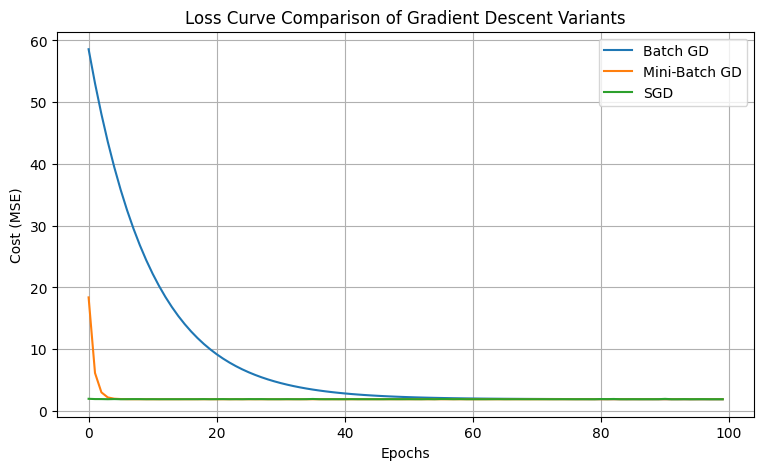

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(cost_batch, label='Batch GD')
plt.plot(cost_mini, label='Mini-Batch GD')
plt.plot(cost_sgd, label='SGD')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Loss Curve Comparison of Gradient Descent Variants')
plt.legend()
plt.grid(True)
plt.show()

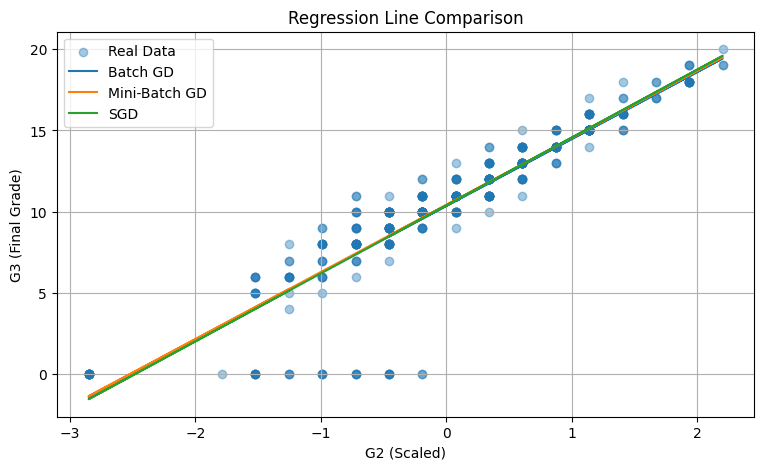

In [25]:
plt.figure(figsize=(9, 5))
plt.scatter(X_single_scaled, y_single, alpha=0.4, label='Real Data')
plt.plot(X_single_scaled, X_bias_single.dot(theta_batch), label='Batch GD')
plt.plot(X_single_scaled, X_bias_single.dot(theta_mini), label='Mini-Batch GD')
plt.plot(X_single_scaled, X_bias_single.dot(theta_sgd), label='SGD')
plt.xlabel('G2 (Scaled)')
plt.ylabel('G3 (Final Grade)')
plt.title('Regression Line Comparison')
plt.legend()
plt.grid(True)
plt.show()

### 16. Interpretation of Results

Linear Regression via Gradient Descent correctly converged to the global minimum, predicting students' final grades with an $R^2$ of 0.7241 (MSE=5.65) and demonstrating that past performance (G1/G2) is the strongest indicator of final success.

Using a learning rate of 0.1 provided the fastest stable convergence without overshooting, unlike smaller rates which failed to converge within 1000 iterations.

Final understanding that we can get from here is that the model is about 72% accurate in explaining the reason why the grades go up or doen and from the interpretations we can see student's background dosent't influence much in the marks but rather how well they performed in the first 2 grading time.